In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from transformers import GPT2Model, GPT2Tokenizer
from torch.nn.functional import cosine_similarity

tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
model = GPT2Model.from_pretrained("gpt2",
                                   output_hidden_states=True)
model.eval()

print("Ready!")

c:\Users\devuser3\AppData\Roaming\uv\python\cpython-3.14.3-windows-x86_64-none\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 148/148 [00:00<00:00, 7205.03it/s]

Ready!


In [2]:
categories = {
    "Royalty":  ["king", "queen", "prince", "princess"],
    "Animals":  ["dog", "cat", "horse", "elephant"],
    "Food":     ["pizza", "burger", "pasta", "rice"],
    "Emotions": ["happy", "sad", "angry", "scared"],
}

def get_all_layers(word):
    inputs = tokenizer(word, return_tensors="pt")
    with torch.no_grad():
        outputs = model(**inputs)
    return [h[0].mean(dim=0) for h in outputs.hidden_states]


all_embeddings = {}
for category, words in categories.items():
    all_embeddings[category] = {}
    for word in words:
        all_embeddings[category][word] = get_all_layers(word)
    print(f"{category} done!")

print("\nReady!")

Royalty done!
Animals done!
Food done!
Emotions done!

Ready!


In [3]:
n_layers = 13
cat_list = list(categories.keys())

within_sims  = {cat: [] for cat in cat_list}
between_sims = []

for layer_idx in range(n_layers):
    
    for category, words in categories.items():
        word_list = list(words)
        embs = [all_embeddings[category][w][layer_idx] 
                for w in word_list]
        
        sims = []
        for i in range(len(embs)):
            for j in range(i+1, len(embs)):
                sim = cosine_similarity(
                    embs[i].unsqueeze(0),
                    embs[j].unsqueeze(0)
                ).item()
                sims.append(sim)
        within_sims[category].append(np.mean(sims))
    
    
    all_embs_layer = []
    all_cats_layer = []
    for category, words in categories.items():
        for word in words:
            all_embs_layer.append(
                all_embeddings[category][word][layer_idx])
            all_cats_layer.append(category)
    
    sims = []
    for i in range(len(all_embs_layer)):
        for j in range(i+1, len(all_embs_layer)):
            if all_cats_layer[i] != all_cats_layer[j]:
                sim = cosine_similarity(
                    all_embs_layer[i].unsqueeze(0),
                    all_embs_layer[j].unsqueeze(0)
                ).item()
                sims.append(sim)
    between_sims.append(np.mean(sims))

print("Calculations done!")
print(f"\nLayer 0  — Within Royalty: {within_sims['Royalty'][0]:.4f}")
print(f"Layer 0  — Between cats:   {between_sims[0]:.4f}")
print(f"Layer 12 — Within Royalty: {within_sims['Royalty'][12]:.4f}")
print(f"Layer 12 — Between cats:   {between_sims[12]:.4f}")

Calculations done!

Layer 0  — Within Royalty: 0.8618
Layer 0  — Between cats:   0.8595
Layer 12 — Within Royalty: 0.9896
Layer 12 — Between cats:   0.9895


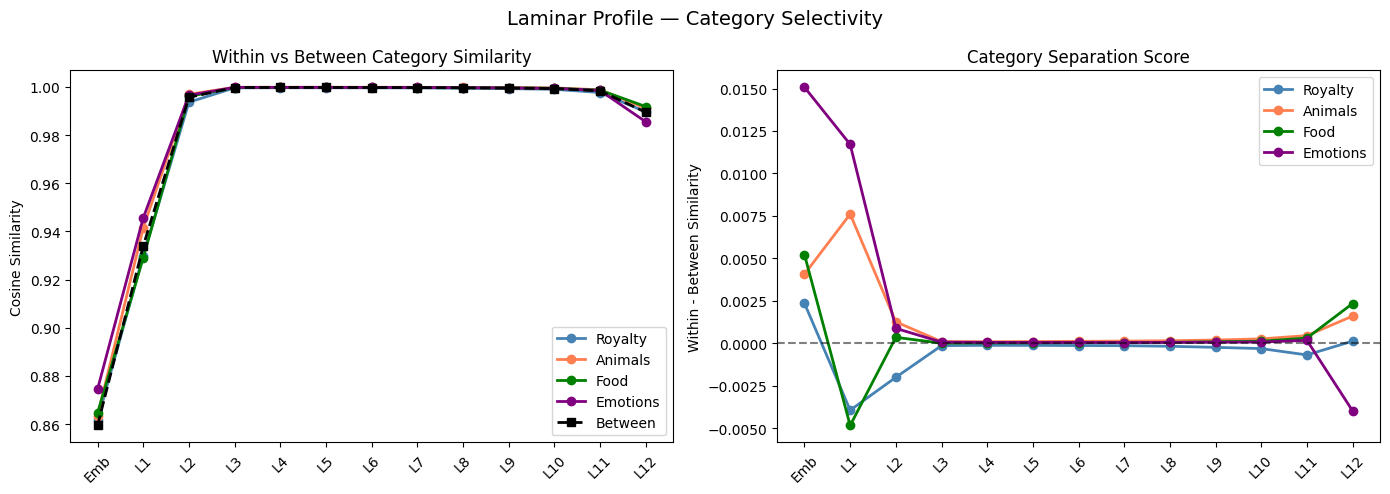

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x       = range(n_layers)
xlabels = ["Emb"] + [f"L{i}" for i in range(1, 13)]
colors  = ["steelblue", "coral", "green", "purple"]


for cat, color in zip(cat_list, colors):
    axes[0].plot(x, within_sims[cat], 
                marker='o', label=cat, 
                color=color, linewidth=2)

axes[0].plot(x, between_sims, 
             marker='s', label="Between", 
             color="black", linewidth=2, linestyle="--")
axes[0].set_xticks(x)
axes[0].set_xticklabels(xlabels, rotation=45)
axes[0].set_ylabel("Cosine Similarity")
axes[0].set_title("Within vs Between Category Similarity")
axes[0].legend()


separations = {cat: [] for cat in cat_list}
for layer_idx in range(n_layers):
    for cat in cat_list:
        sep = within_sims[cat][layer_idx] - between_sims[layer_idx]
        separations[cat].append(sep)

for cat, color in zip(cat_list, colors):
    axes[1].plot(x, separations[cat],
                marker='o', label=cat,
                color=color, linewidth=2)

axes[1].axhline(y=0, color="black", 
                linestyle="--", alpha=0.5)
axes[1].set_xticks(x)
axes[1].set_xticklabels(xlabels, rotation=45)
axes[1].set_ylabel("Within - Between Similarity")
axes[1].set_title("Category Separation Score")
axes[1].legend()

plt.suptitle("Laminar Profile — Category Selectivity", fontsize=14)
plt.tight_layout()
plt.show()

* Within-category vs between-category similarity is very similar
* GPT-2 does not strongly separate categories
* The separation score is very small — less than 0.002
* This confirms that GPT-2 is a general-purpose model
